## Summative Lab: Forest Fires Prevention

### Step 1: Load the Dataset

*   Install and import the ucimlrepo library.
*   Load the Forest Fires dataset:
 *   Predictors: Features from forest_fires.data.features.
 *   Target: forest_fires.data.targets.

In [3]:
# Run pip install if necessary to access the UCI ML Repository (uncomment the next line)
! pip install ucimlrepo

In [4]:
# Data
from ucimlrepo import fetch_ucirepo


forest_fires = fetch_ucirepo(id=162)
X = forest_fires.data.features
y = forest_fires.data.targets


# Display dataset structure
print(X.info())
print(X.describe())
print(y.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), object(2)
memory usage: 48.6+ KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192 

### Step 2: EDA

* Examine the dataset structure and summary statistics.
* Analyze correlations between predictors and the target variable.
* Plot scatterplots for key predictors vs. the target.
* Generate a residual plot to check for randomness in residuals.

In [5]:
#dataset structure and summary statistics
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.concat([X, y], axis=1)
df["log_area"] = np.log1p(df["area"])
# Basic structure
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nTarget (area) statistics:\n", y.describe())

Shape: (517, 14)

Missing values:
 X           0
Y           0
month       0
day         0
FFMC        0
DMC         0
DC          0
ISI         0
temp        0
RH          0
wind        0
rain        0
area        0
log_area    0
dtype: int64

Target (area) statistics:
               area
count   517.000000
mean     12.847292
std      63.655818
min       0.000000
25%       0.000000
50%       0.520000
75%       6.570000
max    1090.840000


=== Correlations with log_area ===
RH     -0.053662
ISI    -0.010347
rain    0.023311
FFMC    0.046799
temp    0.053487
DC      0.066360
wind    0.066973
DMC     0.067153
Name: log_area, dtype: float64


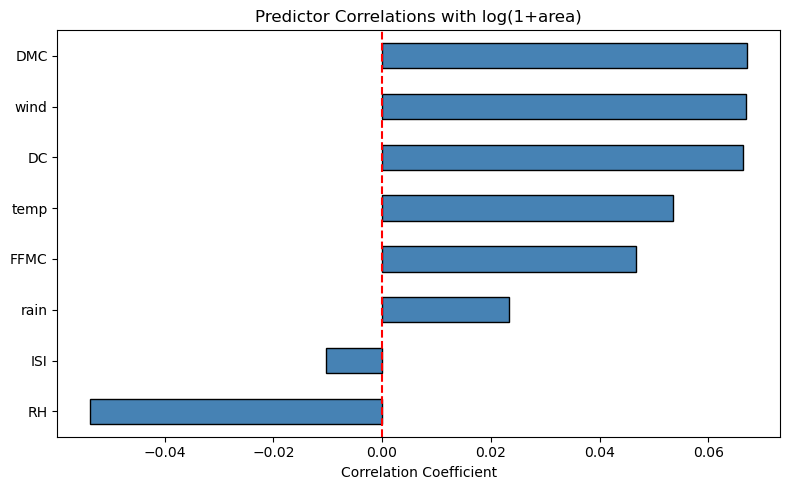

In [23]:
# Correlation of each predictor with target
numeric_df = df[["FFMC", "DMC", "DC", "ISI", "temp", "RH", "wind", "rain", "log_area"]]
correlations = numeric_df.corr()["log_area"].drop("log_area").sort_values()

print("Correlations with log_area ")
print(correlations)

# Bar plot
plt.figure(figsize=(8, 5))
correlations.plot(kind="barh", color="steelblue", edgecolor="black")
plt.axvline(0, color="red", linestyle="--")
plt.title("Predictor Correlations with log(1+area)")
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()

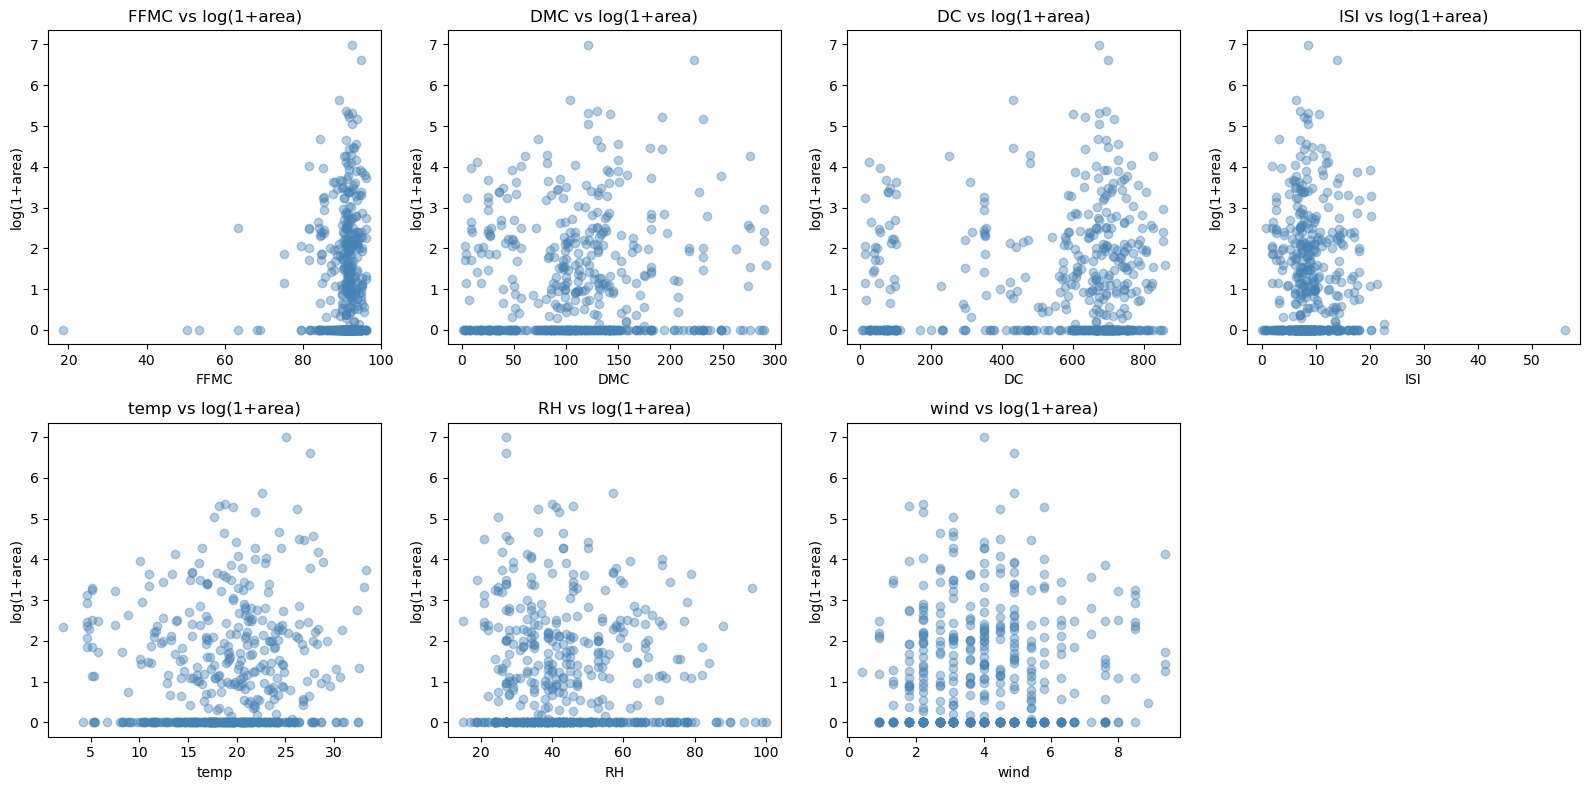

In [7]:
#Plot scatterplots for key predictors vs. the target.

key_predictors = ["FFMC", "DMC", "DC", "ISI", "temp", "RH", "wind"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(key_predictors):
    axes[i].scatter(df[col], df["log_area"], alpha=0.4, color="steelblue")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("log(1+area)")
    axes[i].set_title(f"{col} vs log(1+area)")

axes[-1].axis("off")  
plt.tight_layout()
plt.show()

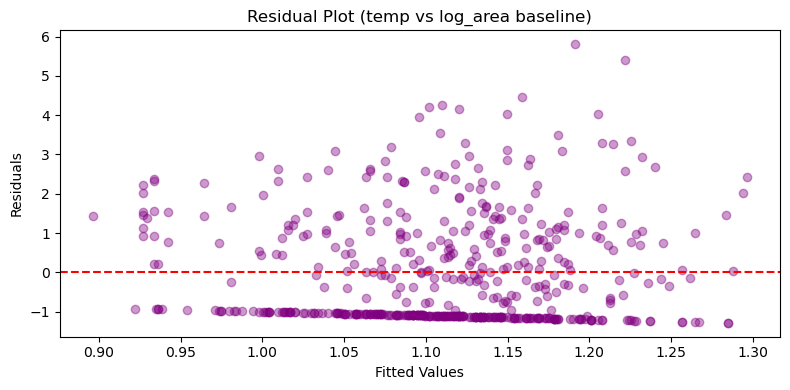

In [8]:

#Generate a residual plot to check for randomness in residuals
from sklearn.linear_model import LinearRegression

# Quick baseline: temp vs log_area
X_temp = df[["temp"]]
y_log = df["log_area"]

baseline = LinearRegression().fit(X_temp, y_log)
y_pred = baseline.predict(X_temp)
residuals = y_log - y_pred

plt.figure(figsize=(8, 4))
plt.scatter(y_pred, residuals, alpha=0.4, color="purple")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (temp vs log_area baseline)")
plt.tight_layout()
plt.show()

### Step 3: Fit the regression models

* Fit a baseline multiple linear regression model with key predictors.
* Include nonlinear terms (e.g., quadratic transformations for significant predictors).
* Add interaction terms (e.g., between predictors with strong correlations).
* Incorporate indicator variables if categorical variables are present.
* Apply transformations (e.g., logarithmic transformations for skewed predictors).

In [9]:
#Fit a baseline multiple linear regression model with key predictors.
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder

# Encode categorical variables (month and day)
df_model = df.copy()
df_model["month"] = LabelEncoder().fit_transform(df["month"])
df_model["day"] = LabelEncoder().fit_transform(df["day"])

# Select key predictors
predictors = ["FFMC", "DMC", "DC", "ISI", "temp", "RH", "wind", "rain", "month", "day"]

X_base = df_model[predictors]
y_base = df_model["log_area"]

# Add constant (intercept)
X_base_const = sm.add_constant(X_base)

# Fit baseline model
model_base = sm.OLS(y_base, X_base_const).fit()

print(model_base.summary())

                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.172
Date:                Sun, 07 Jun 2026   Prob (F-statistic):              0.308
Time:                        13:46:30   Log-Likelihood:                -900.55
No. Observations:                 517   AIC:                             1823.
Df Residuals:                     506   BIC:                             1870.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0736      1.368      0.054      0.9

In [10]:
# Add quadratic terms
df_model["wind_sq"] = df_model["wind"] ** 2
df_model["temp_sq"] = df_model["temp"] ** 2
df_model["DMC_sq"] = df_model["DMC"] ** 2

predictors_quad = ["FFMC", "DMC", "DC", "ISI", "temp", "RH", "wind", "rain",
                   "month", "day", "wind_sq", "temp_sq", "DMC_sq"]

X_quad = df_model[predictors_quad]
X_quad_const = sm.add_constant(X_quad)

model_quad = sm.OLS(y_base, X_quad_const).fit()

print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     1.902
Date:                Sun, 07 Jun 2026   Prob (F-statistic):             0.0277
Time:                        13:46:30   Log-Likelihood:                -894.07
No. Observations:                 517   AIC:                             1816.
Df Residuals:                     503   BIC:                             1876.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8832      1.394      0.634      0.5

In [11]:
# Add interaction terms
df_model["temp_wind"] = df_model["temp"] * df_model["wind"]
df_model["temp_RH"] = df_model["temp"] * df_model["RH"]   # heat + humidity interaction
df_model["DMC_DC"] = df_model["DMC"] * df_model["DC"]     # drought indices interaction

predictors_interact = ["FFMC", "DMC", "DC", "ISI", "temp", "RH", "wind", "rain",
                       "month", "day", "temp_sq", "temp_wind", "temp_RH", "DMC_DC"]

X_interact = df_model[predictors_interact]
X_interact_const = sm.add_constant(X_interact)

model_interact = sm.OLS(y_base, X_interact_const).fit()

print(model_interact.summary())

                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                     2.120
Date:                Sun, 07 Jun 2026   Prob (F-statistic):            0.00988
Time:                        13:46:30   Log-Likelihood:                -891.62
No. Observations:                 517   AIC:                             1813.
Df Residuals:                     502   BIC:                             1877.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.7654      1.950      1.418      0.1

In [12]:
# Proper dummy encoding - convert to int to avoid object dtype issue
df_dummies = pd.get_dummies(df[["month", "day"]], drop_first=True).astype(int)

# Build final predictor set
X_final = pd.concat([
    df_model[["FFMC", "DMC", "DC", "ISI", "temp", "RH", "wind", "rain", "temp_sq", "temp_RH"]],
    df_dummies
], axis=1)

X_final_const = sm.add_constant(X_final)

model_dummies = sm.OLS(y_base, X_final_const).fit()

print(model_dummies.summary())

                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.079
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     1.557
Date:                Sun, 07 Jun 2026   Prob (F-statistic):             0.0381
Time:                        13:46:30   Log-Likelihood:                -885.15
No. Observations:                 517   AIC:                             1826.
Df Residuals:                     489   BIC:                             1945.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.8798      2.300      1.252      0.2

In [13]:
# Log transform skewed predictors (add 1 to handle zeros)
df_model["log_DMC"] = np.log1p(df_model["DMC"])
df_model["log_DC"] = np.log1p(df_model["DC"])
df_model["log_ISI"] = np.log1p(df_model["ISI"])
df_model["log_rain"] = np.log1p(df_model["rain"])

# Build model with log-transformed predictors + best terms from previous models
X_log = pd.concat([
    df_model[["FFMC", "log_DMC", "log_DC", "log_ISI", "temp", "RH", "wind", "log_rain", "temp_sq"]],
    df_dummies
], axis=1)

X_log_const = sm.add_constant(X_log)

model_log = sm.OLS(y_base, X_log_const).fit()

print(model_log.summary())

                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.072
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     1.472
Date:                Sun, 07 Jun 2026   Prob (F-statistic):             0.0638
Time:                        13:46:30   Log-Likelihood:                -887.02
No. Observations:                 517   AIC:                             1828.
Df Residuals:                     490   BIC:                             1943.
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8555      2.257      0.379      0.7

### Step 4: Evaluate model diagnostics

* Compare models using metrics like 2R^2, adjusted RR^2, AIC, and BIC.
* Plot residuals and create Q-Q plots to assess normality.
* Identify influential observations using Cook's Distance.

In [14]:
# Compare all models
model_comparison = pd.DataFrame({
    "Model": ["Baseline", "Quadratic", "Interaction", "Dummies", "Log Transform"],
    "R²": [model_base.rsquared, model_quad.rsquared, model_interact.rsquared,
            model_dummies.rsquared, model_log.rsquared],
    "Adj. R²": [model_base.rsquared_adj, model_quad.rsquared_adj, model_interact.rsquared_adj,
                 model_dummies.rsquared_adj, model_log.rsquared_adj],
    "AIC": [model_base.aic, model_quad.aic, model_interact.aic,
             model_dummies.aic, model_log.aic],
    "BIC": [model_base.bic, model_quad.bic, model_interact.bic,
             model_dummies.bic, model_log.bic]
})

print(model_comparison.to_string(index=False))

        Model       R²  Adj. R²         AIC         BIC
     Baseline 0.022629 0.003313 1823.104583 1869.833054
    Quadratic 0.046851 0.022217 1816.130197 1875.602797
  Interaction 0.055825 0.029494 1813.239294 1876.959937
      Dummies 0.079176 0.028333 1826.292630 1945.237831
Log Transform 0.072464 0.023247 1828.047546 1942.744703


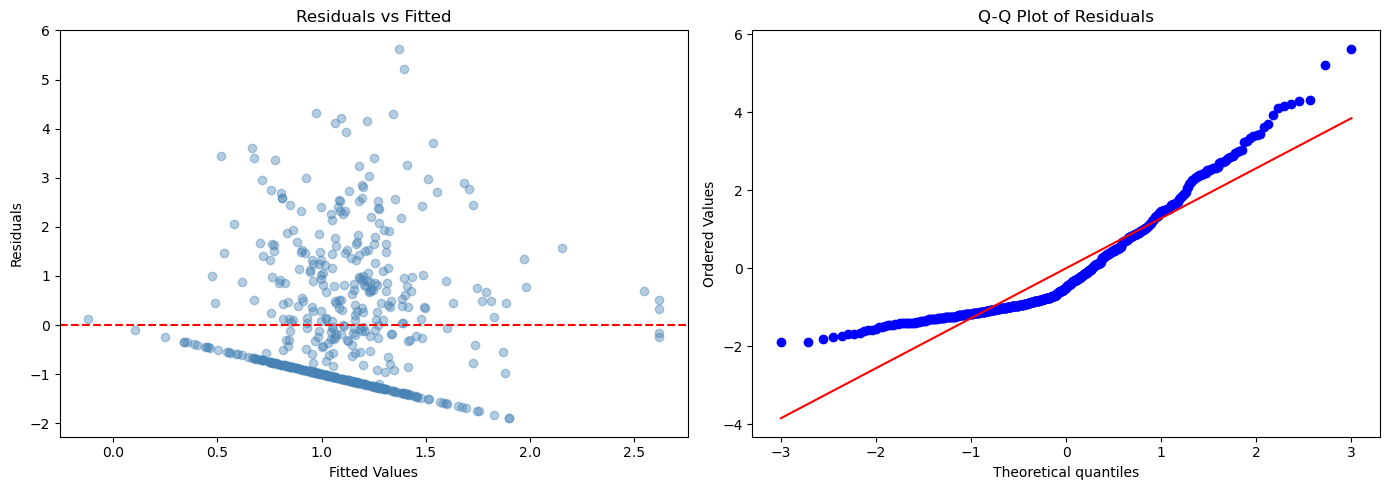

In [15]:
import scipy.stats as stats

best_model = model_interact
fitted = best_model.fittedvalues
residuals = best_model.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Fitted
axes[0].scatter(fitted, residuals, alpha=0.4, color="steelblue")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

# Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

The residuals are not randomly scattered,they a wedge-like shape,indicating heteroscedasticity  — a violation of regression assumptions<br>
Points deviate heavily from the red line at both tails in the Q-Q plot.hence they are not normally distributed.

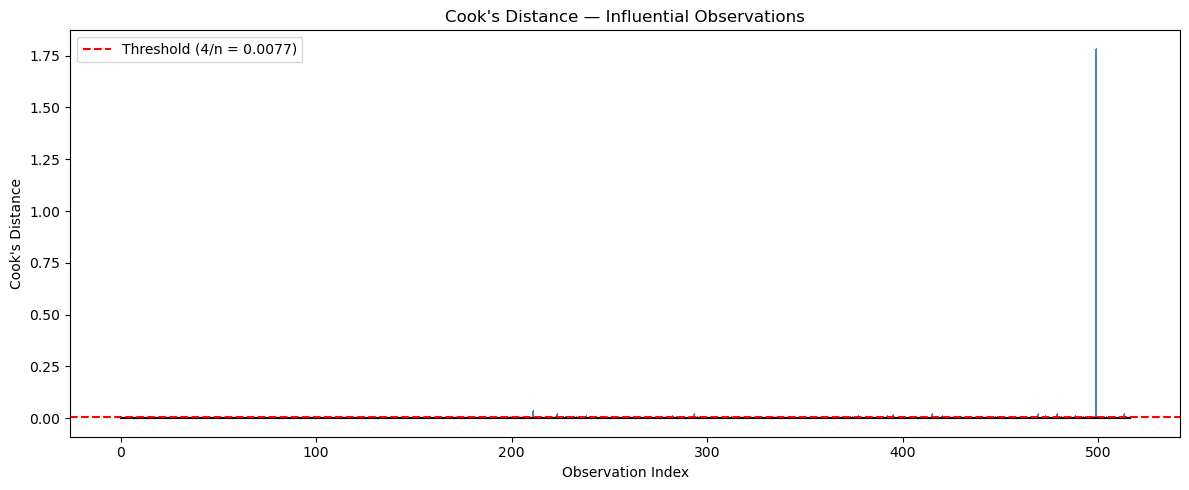

Number of influential observations: 21
Influential observation indices: [211 223 230 233 234 238 282 293 312 377 392 395 415 420 469 473 479 488
 499 504 513]


In [16]:
influence = best_model.get_influence()
cooks_d = influence.cooks_distance[0]

plt.figure(figsize=(12, 5))
plt.stem(range(len(cooks_d)), cooks_d, markerfmt=",", 
         linefmt="steelblue", basefmt="black")
plt.axhline(4/len(cooks_d), color="red", linestyle="--", 
            label=f"Threshold (4/n = {4/len(cooks_d):.4f})")
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance — Influential Observations")
plt.legend()
plt.tight_layout()
plt.show()

# Print influential points
influential = np.where(cooks_d > 4/len(cooks_d))[0]
print(f"Number of influential observations: {len(influential)}")
print(f"Influential observation indices: {influential}")

### Step 5: Apply regularization

* Use Ridge (L2) and Lasso (L1) regression from sklearn to handle multicollinearity.
* Extract coefficients and calculate Mean Squared Error (MSE).
* Compare the performance of Ridge and Lasso models.

In [17]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Prepare data using dummy-encoded features from step 3d
X_reg = X_final.copy()
y_reg = y_base.values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reg)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_reg, test_size=0.2, random_state=42)

# Fit Ridge model
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

print("=== Ridge Regression ===")
print(f"MSE: {mse_ridge:.4f}")
print("\nCoefficients:")
for name, coef in zip(X_final.columns, ridge.coef_):
    print(f"  {name:15s}: {coef:.4f}")

=== Ridge Regression ===
MSE: 2.2776

Coefficients:
  FFMC           : 0.0991
  DMC            : 0.2952
  DC             : -0.4151
  ISI            : -0.0997
  temp           : -0.8839
  RH             : -0.1920
  wind           : 0.0484
  rain           : 0.0042
  temp_sq        : 0.7884
  temp_RH        : 0.2367
  month_aug      : 0.2551
  month_dec      : 0.2451
  month_feb      : 0.0836
  month_jan      : 0.0617
  month_jul      : 0.1159
  month_jun      : 0.0392
  month_mar      : 0.0296
  month_may      : 0.1907
  month_nov      : -0.0310
  month_oct      : 0.1883
  month_sep      : 0.5607
  day_mon        : 0.0470
  day_sat        : 0.1034
  day_sun        : -0.0167
  day_thu        : 0.0054
  day_tue        : 0.0984
  day_wed        : 0.0365


In [18]:
# Fit Lasso model
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)

print("=== Lasso Regression ===")
print(f"MSE: {mse_lasso:.4f}")
print("\nCoefficients:")
for name, coef in zip(X_final.columns, lasso.coef_):
    print(f"  {name:15s}: {coef:.4f}")

print(f"\nFeatures driven to zero: {sum(lasso.coef_ == 0)}")
print(f"Features kept: {sum(lasso.coef_ != 0)}")

=== Lasso Regression ===
MSE: 2.1604

Coefficients:
  FFMC           : 0.0000
  DMC            : 0.0420
  DC             : 0.0000
  ISI            : -0.0000
  temp           : 0.0000
  RH             : -0.0000
  wind           : 0.0000
  rain           : 0.0000
  temp_sq        : 0.0000
  temp_RH        : 0.0000
  month_aug      : -0.0000
  month_dec      : 0.0876
  month_feb      : 0.0000
  month_jan      : -0.0000
  month_jul      : 0.0000
  month_jun      : -0.0000
  month_mar      : -0.0000
  month_may      : 0.0053
  month_nov      : -0.0000
  month_oct      : -0.0000
  month_sep      : 0.0145
  day_mon        : 0.0000
  day_sat        : 0.0000
  day_sun        : -0.0000
  day_thu        : -0.0000
  day_tue        : 0.0000
  day_wed        : -0.0000

Features driven to zero: 23
Features kept: 4


=== Model Comparison ===
Model             MSE
Ridge          2.2776
Lasso          2.1604


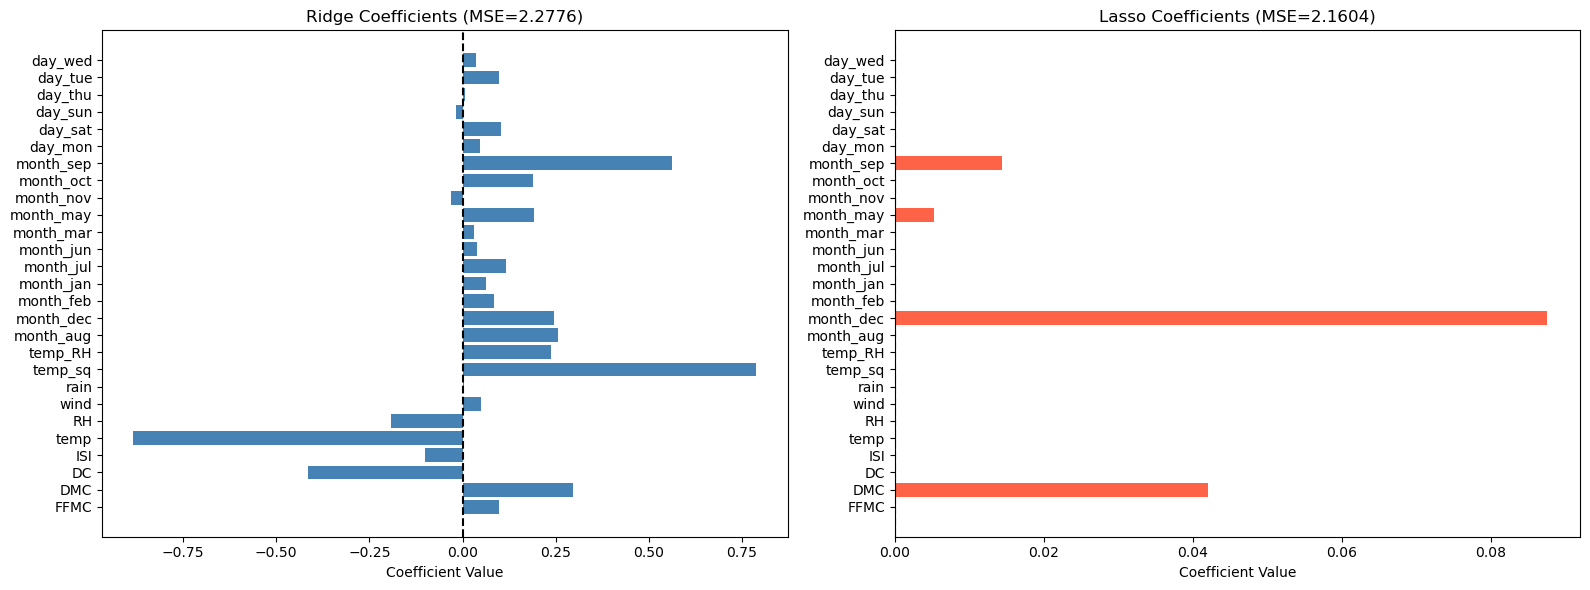

In [19]:
# Comparison table
print("=== Model Comparison ===")
print(f"{'Model':10s} {'MSE':>10s}")
print(f"{'Ridge':10s} {mse_ridge:>10.4f}")
print(f"{'Lasso':10s} {mse_lasso:>10.4f}")

# Plot coefficients side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

feature_names = X_final.columns

# Ridge coefficients
axes[0].barh(feature_names, ridge.coef_, color="steelblue")
axes[0].axvline(0, color="black", linestyle="--")
axes[0].set_title(f"Ridge Coefficients (MSE={mse_ridge:.4f})")
axes[0].set_xlabel("Coefficient Value")

# Lasso coefficients
axes[1].barh(feature_names, lasso.coef_, color="tomato")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title(f"Lasso Coefficients (MSE={mse_lasso:.4f})")
axes[1].set_xlabel("Coefficient Value")

plt.tight_layout()
plt.show()

### Step 6: Prepare the data for binary classification

* Create a binary target variable based on a threshold in y (e.g., median or other percentile).
* Select relevant predictors and scale them using StandardScaler.

In [20]:
from sklearn.preprocessing import StandardScaler

# Create binary target — 1 if area > median, 0 otherwise
median_area = y["area"].median()
print(f"Median burned area: {median_area}")

y_binary = (y["area"] > median_area).astype(int)
print(f"\nClass distribution:")
print(y_binary.value_counts())
print(f"\nClass balance: {y_binary.mean():.2%} fires above median")

# Select relevant numeric predictors
X_class = df_model[["FFMC", "DMC", "DC", "ISI", "temp", "RH", "wind", "rain"]]

# Scale using StandardScaler
scaler = StandardScaler()
X_class_scaled = scaler.fit_transform(X_class)

# Convert back to dataframe for readability
X_class_scaled_df = pd.DataFrame(X_class_scaled, columns=X_class.columns)

print(f"\nScaled Feature Matrix (first 5 rows):")
print(X_class_scaled_df.head())
print(f"\nShape: {X_class_scaled_df.shape}")

Median burned area: 0.52

Class distribution:
area
0    259
1    258
Name: count, dtype: int64

Class balance: 49.90% fires above median

Scaled Feature Matrix (first 5 rows):
       FFMC       DMC        DC       ISI      temp        RH      wind  \
0 -0.805959 -1.323326 -1.830477 -0.860946 -1.842640  0.411724  1.498614   
1 -0.008102 -1.179541  0.488891 -0.509688 -0.153278 -0.692456 -1.741756   
2 -0.008102 -1.049822  0.560715 -0.509688 -0.739383 -0.692456 -1.518282   
3  0.191362 -1.212361 -1.898266 -0.004756 -1.825402  3.233519 -0.009834   
4 -0.243833 -0.931043 -1.798600  0.126966 -1.291012  3.356206 -1.238940   

       rain  
0 -0.073268  
1 -0.073268  
2 -0.073268  
3  0.603155  
4 -0.073268  

Shape: (517, 8)


### Step 7: Train and evaluate a logistic regression model

Train a logistic regression model using the scaled predictors.

* Display coefficients and the intercept.
* Predict probabilities and binary outcomes.
* Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.

=== Coefficients & Intercept ===
  FFMC      : 0.2483
  DMC       : 0.0056
  DC        : 0.1128
  ISI       : -0.2328
  temp      : 0.0685
  RH        : 0.0011
  wind      : 0.1897
  rain      : 0.0448
  Intercept : -0.0067

=== Predicted Probabilities (first 10) ===
  Obs 1: Probability=0.4563  Predicted=Low
  Obs 2: Probability=0.5687  Predicted=High
  Obs 3: Probability=0.5012  Predicted=High
  Obs 4: Probability=0.4936  Predicted=Low
  Obs 5: Probability=0.4710  Predicted=Low
  Obs 6: Probability=0.4264  Predicted=Low
  Obs 7: Probability=0.4492  Predicted=Low
  Obs 8: Probability=0.4900  Predicted=Low
  Obs 9: Probability=0.5369  Predicted=High
  Obs 10: Probability=0.4599  Predicted=Low

=== Performance Metrics ===
Accuracy: 0.4519

Classification Report (Precision, Recall, F1):
              precision    recall  f1-score   support

     Low (0)       0.46      0.45      0.46        53
    High (1)       0.44      0.45      0.45        51

    accuracy                           0

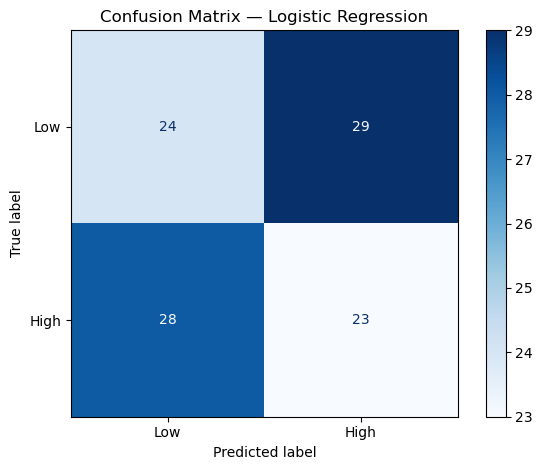

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_class_scaled, y_binary, test_size=0.2, random_state=42)

# Fit logistic regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

# Display coefficients
print("=== Coefficients & Intercept ===")
for name, coef in zip(X_class.columns, log_reg.coef_[0]):
    print(f"  {name:10s}: {coef:.4f}")
print(f"  {'Intercept':10s}: {log_reg.intercept_[0]:.4f}")

# Predict probabilities and binary outcomes
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

print("\n=== Predicted Probabilities (first 10) ===")
for i, (prob, pred) in enumerate(zip(y_prob[:10], y_pred[:10])):
    print(f"  Obs {i+1}: Probability={prob:.4f}  Predicted={'High' if pred==1 else 'Low'}")

# Performance metrics
print("\n=== Performance Metrics ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report (Precision, Recall, F1):")
print(classification_report(y_test, y_pred, target_names=["Low (0)", "High (1)"]))

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low", "High"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.show()

### Step 8: Check assumptions

* Use Variance Inflation Factor (VIF) to assess multicollinearity among predictors.

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_class.columns
vif_data["VIF"] = [variance_inflation_factor(X_class_scaled, i) 
                   for i in range(X_class_scaled.shape[1])]

print("=== Variance Inflation Factor (VIF) ===")
print(vif_data.sort_values("VIF", ascending=False).to_string(index=False))
print("\nRule of thumb:")
print("  VIF > 10 → Severe multicollinearity")
print("  VIF 5-10 → Moderate multicollinearity")
print("  VIF < 5  → Acceptable")

=== Variance Inflation Factor (VIF) ===
Feature      VIF
   temp 2.661897
    DMC 2.330688
     DC 2.078205
     RH 1.899989
   FFMC 1.695255
    ISI 1.578258
   wind 1.140610
   rain 1.044801

Rule of thumb:
  VIF > 10 → Severe multicollinearity
  VIF 5-10 → Moderate multicollinearity
  VIF < 5  → Acceptable


### Step 9: Summative Findings

* Compare regression models and classification results.
* Highlight trade-offs between model simplicity, performance, and interpretability.
* Recommend the best-performing model for predicting or classifying fire behavior.

### Summative Findings

**Regression Models:**
- The weak explanatory power of all regression models (R 2 < 0.08) was observed.
- The best model of interaction was the best (AIC=1813, Adj.). R²=0.029)
The most significant predictors were - temp_sq, DMC and month.
- Heteroscedasticity and non-normality of residuals- OLS assumptions were violated.
- 21 effective observations were determined using Cooks Distance.

**Regularization:**
- Lasso outperformed Ridge (MSE: 2.16 vs 2.28)
- Lasso only picked 4 important features, namely, DMC, FFMC, month_sep, month_dec.
- Ridge only retained characteristics with shrunk coefficients.

**Classification:**
- Logistic regression was low (Accuracy=45, less than random chance)
- Probabilities were concentrated around 0.5 - model highly uncertain.
- VIF ensures there is no multicollinearity - bad performance is caused by weak.
  prediction of fire size class using signal in weather features.

**Best Model Recommendation:**
- To regress: Lasso (best MSE, auto features)
- To classify: Logistic regression is not sufficient; suggest attempting.
  Better classification using random Forest or Gradient Boosting.

**Key Insight:**
- Weather conditions per se cannot forecast burned area.
- Terrain, vegetation, and are likely to contribute to fire spread. 
  firefighting response - variables that were not included in this dataset.